In [1]:
import galsim
from galsim import hsm
import matplotlib.pyplot as plt
import h5py
import numpy as np

0.024767035618424416 -0.011320454999804497 galsim.Shear(g1=0.012385814437344954,g2=-0.005661277236973273)


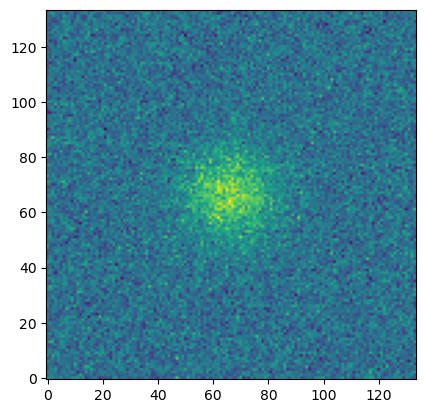

In [2]:
gal_flux = 1.e5    # total counts on the image
gal_sigma = 2.     # arcsec
psf_sigma = 1.     # arcsec
pixel_scale = 0.2  # arcsec / pixel
noise = 30.        # standard deviation of the counts in each pixel
gal = galsim.Gaussian(flux=gal_flux, sigma=gal_sigma)


psf = galsim.Gaussian(flux=1., sigma=psf_sigma) # PSF flux should always = 1
final = galsim.Convolve([gal, psf])
image = final.drawImage(scale=pixel_scale)
image.addNoise(galsim.GaussianNoise(sigma=noise))


results = image.FindAdaptiveMom()
plt.imshow(image.array,origin='lower')
print(results.observed_e1,results.observed_e2,results.observed_shape)

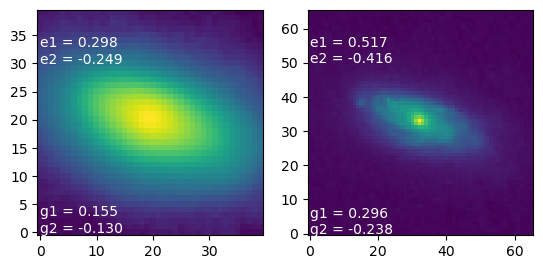

In [24]:
randind = np.random.randint(1000)
with h5py.File('../data/Nircam_train_cosmos.hdf5', 'r', swmr=True) as hr_hdf5:
    hr_image = hr_hdf5["train_img"][randind, ...]

with h5py.File('../data/Nisp_train_cosmos.hdf5', 'r', swmr=True) as lr_hdf5:
    lr_image = lr_hdf5["train_img"][randind, ...]

real_image = galsim.ImageF(40,40)
real_image.array = lr_image[0,:,:]
plt.subplot(1,2,1)
plt.imshow(real_image.array,origin='lower')
results = real_image.FindAdaptiveMom()
plt.text(0,30,"e1 = %.3f\ne2 = %.3f"%(results.observed_e1,results.observed_e2),color='white')
plt.text(0,0, "g1 = %.3f\ng2 = %.3f"%(results.observed_shape.g1,results.observed_shape.g2),color='white')


real_image = galsim.ImageF(66,66)
real_image.array = hr_image[0,:,:]
plt.subplot(1,2,2)
plt.imshow(real_image.array,origin='lower')
results = real_image.FindAdaptiveMom()
plt.text(0,50,"e1 = %.3f\ne2 = %.3f"%(results.observed_e1,results.observed_e2),color='white')
plt.text(0,0, "g1 = %.3f\ng2 = %.3f"%(results.observed_shape.g1,results.observed_shape.g2),color='white')

plt.show()